In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.style.use('ggplot')


Imported the Libraries.

In [41]:
#load the datset
df = pd.read_csv("ecommerce_customer_dataset.csv")
#view the datset
df.head()

,customer_id,age,gender,annual_income_k$,spending_score
0,C0001,58,Female,71,38.5
1,C0002,25,Female,139,86.0
2,C0003,19,Male,71,37.6
3,C0004,65,Male,84,63.0
4,C0005,35,Male,126,74.3


In [42]:
df.shape

(300, 5)

In [43]:
df.columns

Index(['customer_id', 'age', 'gender', 'annual_income_k$', 'spending_score'], dtype='str')

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       300 non-null    str    
 1   age               300 non-null    int64  
 2   gender            300 non-null    str    
 3   annual_income_k$  300 non-null    int64  
 4   spending_score    300 non-null    float64
dtypes: float64(1), int64(2), str(2)
memory usage: 11.8 KB


In [45]:
df.describe()

,age,annual_income_k$,spending_score
count,300.00000,300.00000,300.000000
mean,43.41000,83.69000,51.384000
std,15.28531,38.51856,20.195202
min,18.00000,15.00000,2.400000
25%,31.00000,50.50000,37.300000
50%,43.00000,84.00000,52.350000
75%,56.25000,119.00000,66.100000
max,70.00000,150.00000,94.200000


In [46]:
#chck missing values
df.isnull().sum()

customer_id         0
age                 0
gender              0
annual_income_k$    0
spending_score      0
dtype: int64

In [47]:
#check Duplicate records
df.duplicated().sum()

np.int64(0)

In [48]:
#verify the datsset
df.shape

(300, 5)

## Data Cleaning Summary

- Dataset loaded successfully.
- Checked for missing values.
- Removed duplicate records (if any).
- Dataset is now ready for analysis.

In [49]:
#descriptove stats
df.describe()

,age,annual_income_k$,spending_score
count,300.00000,300.00000,300.000000
mean,43.41000,83.69000,51.384000
std,15.28531,38.51856,20.195202
min,18.00000,15.00000,2.400000
25%,31.00000,50.50000,37.300000
50%,43.00000,84.00000,52.350000
75%,56.25000,119.00000,66.100000
max,70.00000,150.00000,94.200000


In [50]:
#avg age
print("Average age :", round(df["age"].mean(),2))

Average age : 43.41


In [51]:
#avg income
print("annual_income_k$ :", round(df["annual_income_k$"].mean(),2))

annual_income_k$ : 83.69


In [52]:
#avd spending score
print("spending_score :", round(df["spending_score"].mean(),2))

spending_score : 51.38


## Descriptive Statistics

- Calculated average customer age.
- Calculated average annual income.
- Calculated average spending score.
- These metrics provide an overview of customer demographics.

In [53]:
features = df[['age', 'annual_income_k$', 'spending_score']]
features.head()

,age,annual_income_k$,spending_score
0,58,71,38.5
1,25,139,86.0
2,19,71,37.6
3,65,84,63.0
4,35,126,74.3


## Feature Selection

For customer segmentation, only the numerical features **Age**, **Annual Income**, and **Spending Score** were selected. These attributes represent customer demographics and purchasing behavior, making them suitable for clustering.


In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features
scaled_df = pd.DataFrame(
    scaled_features,
    columns=['Age', 'Annual Income', 'Spending Score']
)

scaled_df.head()

,Age,Annual Income,Spending Score
0,0.956106,-0.330002,-0.639039
1,-1.206437,1.438330,1.716934
2,-1.599626,-0.330002,-0.683679
3,1.414827,0.008062,0.576147
4,-0.551121,1.100267,1.136621


## Data Standardization

The selected features were standardized using **StandardScaler** to ensure they have a mean of 0 and a standard deviation of 1. Standardization prevents features with larger values from dominating the clustering process.

In [55]:
#Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

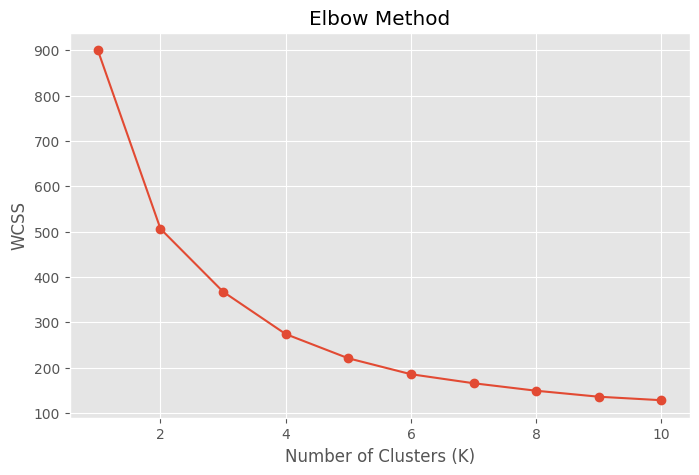

In [56]:
#plot elbow curve
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()

## Observation

The Elbow Method was used to determine the optimal number of clusters. The point where the WCSS curve starts to flatten indicates the ideal value of **K** for customer segmentation.

The Elbow Method indicates that **4 clusters** is the optimal choice for customer segmentation. After K = 4, the decrease in WCSS becomes gradual, suggesting that adding more clusters provides only a small improvement.

In [57]:
#apply K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(scaled_df)

df.head()

,customer_id,age,gender,annual_income_k$,spending_score,Cluster
0,C0001,58,Female,71,38.5,0
1,C0002,25,Female,139,86.0,3
2,C0003,19,Male,71,37.6,2
3,C0004,65,Male,84,63.0,1
4,C0005,35,Male,126,74.3,3


In [58]:
df['Cluster'].value_counts()

Cluster
2    78
0    74
3    74
1    74
Name: count, dtype: int64

## Cluster Summary

Customers have been divided into **4 distinct groups** based on Age, Annual Income, and Spending Score using the K-Means clustering algorithm.


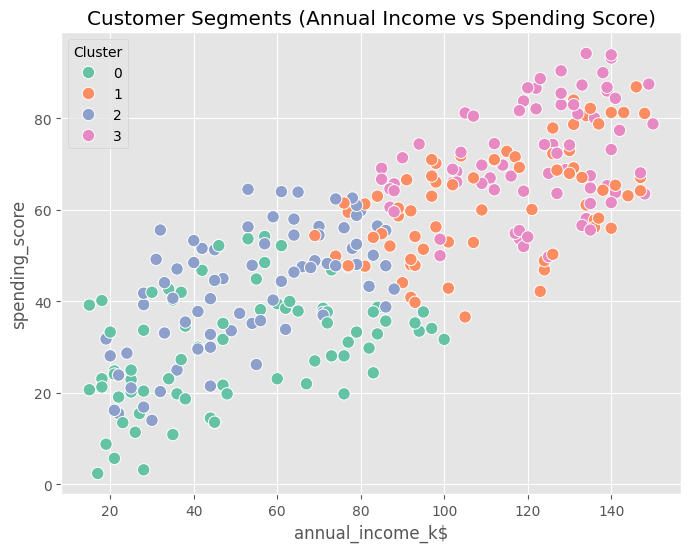

In [62]:
#Anual inc vs Spending score
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='annual_income_k$',
    y='spending_score',
    hue='Cluster',
    palette='Set2',
    s=80
)

plt.title("Customer Segments (Annual Income vs Spending Score)")
plt.show()


### Observation

The scatter plot clearly separates customers into four different segments based on their annual income and spending score. These clusters represent groups with similar purchasing behavior.

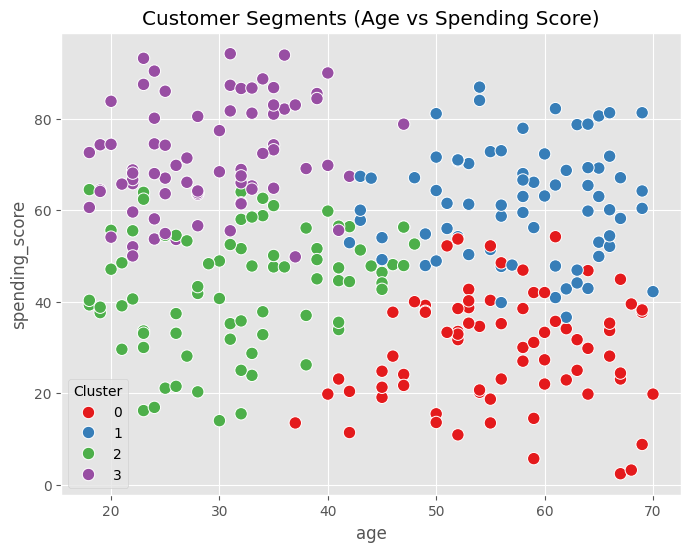

In [63]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='age',
    y='spending_score',
    hue='Cluster',
    palette='Set1',
    s=80
)

plt.title("Customer Segments (Age vs Spending Score)")
plt.show()

### Observation

The visualization shows how customer age influences spending behavior. Different age groups exhibit different spending patterns, making age an important factor in customer segmentation.

In [67]:
#cluster [profiling
cluster_profile = df.groupby('Cluster')[['age', 'annual_income_k$', 'spending_score']].mean().round(2)
cluster_profile
df['Cluster'].value_counts().sort_index()

Cluster
0    74
1    74
2    78
3    74
Name: count, dtype: int64

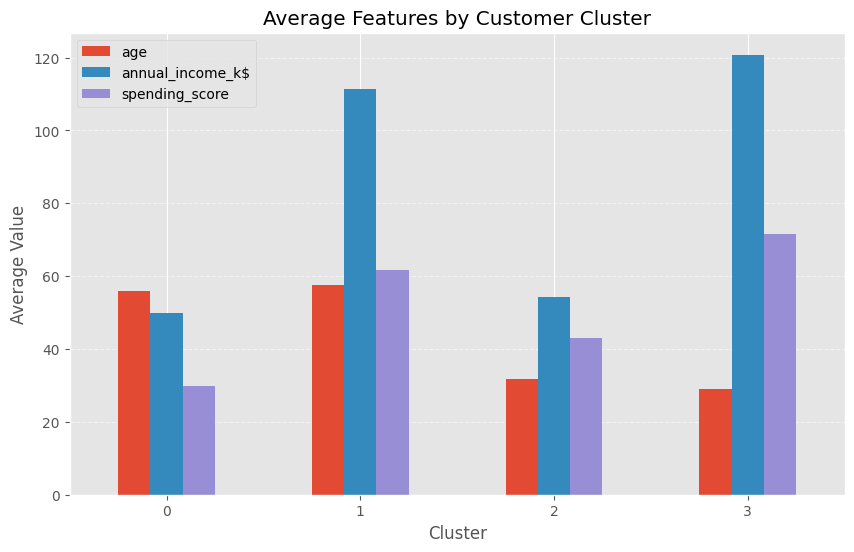

In [68]:
#cluster profil visualisation
cluster_profile.plot(kind='bar', figsize=(10,6))

plt.title("Average Features by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [69]:
print(cluster_profile)

           age  annual_income_k$  spending_score
Cluster                                         
0        56.01             50.01           29.71
1        57.50            111.31           61.65
2        31.74             54.26           43.09
3        29.01            120.77           71.54


Observation
Cluster 0: Customers have lower annual income and low spending scores, indicating price-sensitive customers.
Cluster 1: Customers have high annual income with moderate spending, suggesting financially strong but selective buyers.
Cluster 2: Customers are younger with moderate income and average spending, representing regular customers.
Cluster 3: Customers have the highest annual income and the highest spending score, making them the most valuable customer segment.

C:\Users\Zarna\AppData\Local\Temp\ipykernel_7044\658510127.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=df, palette='Set2')


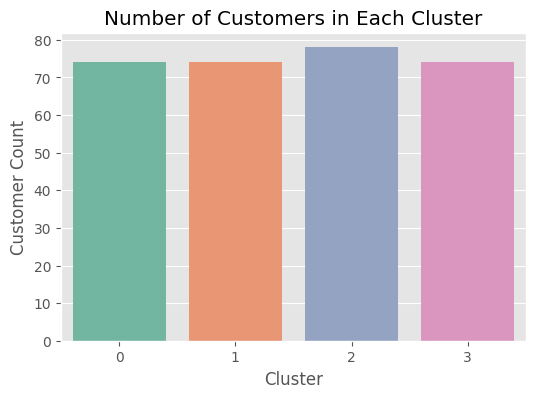

In [70]:
plt.figure(figsize=(6,4))

sns.countplot(x='Cluster', data=df, palette='Set2')

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Customer Count")

plt.show()

### Observation

The chart shows the distribution of customers across the four clusters. The clusters are reasonably balanced, indicating that the K-Means algorithm has effectively segmented customers without creating highly uneven groups.

## Business Value

The customer segmentation analysis provides valuable insights into customer purchasing behavior by grouping customers with similar characteristics. The analysis identified four distinct customer segments based on Age, Annual Income, and Spending Score.

These insights enable businesses to:
- Design personalized marketing campaigns for different customer groups.
- Focus premium products and loyalty programs on high-value customers.
- Increase engagement of moderate-spending customers through targeted promotions.
- Improve customer retention and optimize marketing investments by allocating resources to the most profitable segments.

Overall, customer segmentation supports data-driven decision-making and helps businesses improve sales performance, customer satisfaction, and long-term profitability.

## Conclusion

This project successfully applied the K-Means clustering algorithm to segment customers based on Age, Annual Income, and Spending Score. Using the Elbow Method, the optimal number of clusters was determined as four.

The analysis revealed distinct customer groups, including high-value customers with high income and spending, moderate customers, and lower-spending customer segments. These findings demonstrate that customers exhibit different purchasing behaviors and should not be treated as a single group.

The generated customer segments can help businesses implement targeted marketing strategies, improve customer retention, increase revenue, and make informed business decisions. Overall, this project highlights the importance of data-driven customer segmentation in enhancing business growth and customer relationship management.